In [13]:
import os
import sys
sys.path.append(os.path.abspath('..'))
from src.analysis import book_analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.preprocessing import tokenize_text
from src.metrics import calculate_mattr
from src.metrics import calculate_ttr
from config.config import CLEAN_DATA_PATH
from config.config import PLOTS_PATH
from src.utils import save_plot


In [14]:
data_path=CLEAN_DATA_PATH
df=book_analysis(data_path)

In [15]:
df


,book,ttr,mattr,rw_ttr,normalized_ttr,normalized_mattr,normalized_rw_ttr,LRI
0,great_expectations,0.131785,0.827749,0.685866,0.100888,0.238424,0.312006,0.232991
1,hamlet,0.283258,0.819389,0.748017,1.000000,0.129221,1.000000,0.564610
2,huckleberry_finn,0.133223,0.809497,0.718561,0.109423,0.000000,0.673925,0.224062
3,moby_dick,0.188744,0.886052,0.690151,0.438984,1.000000,0.359440,0.695629
4,pride_and_prejudice,0.114788,0.876499,0.657681,0.000000,0.875207,0.000000,0.437604


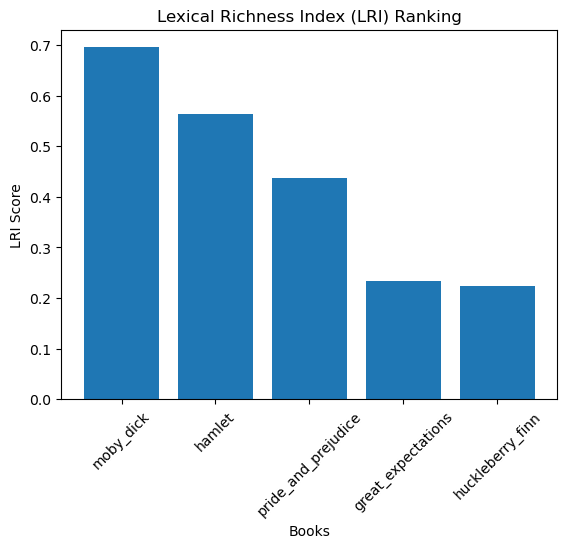

In [16]:
df_sorted = df.sort_values(by="LRI", ascending=False)

plt.figure()
plt.bar(df_sorted["book"], df_sorted["LRI"])

plt.title("Lexical Richness Index (LRI) Ranking")
plt.xlabel("Books")
plt.ylabel("LRI Score")
plt.xticks(rotation=45)

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'LRI_bar_plot.png')
plt.show()



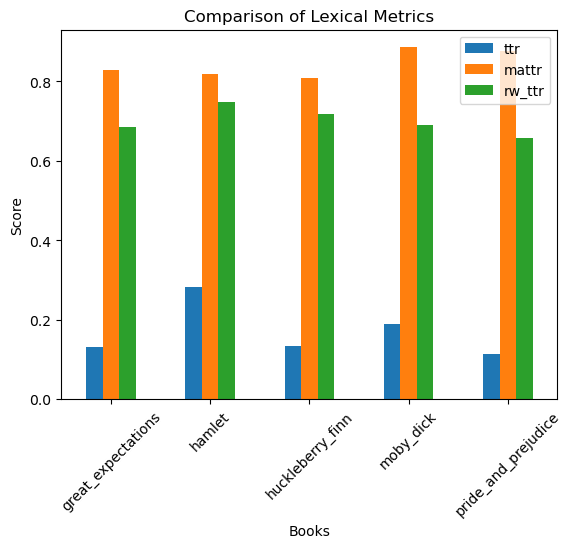

In [17]:
df.set_index("book")[["ttr", "mattr", "rw_ttr"]].plot(kind="bar")

plt.title("Comparison of Lexical Metrics")
plt.xlabel("Books")
plt.ylabel("Score")
plt.xticks(rotation=45)

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'Lexical_metrics_comparison.png')

plt.show()

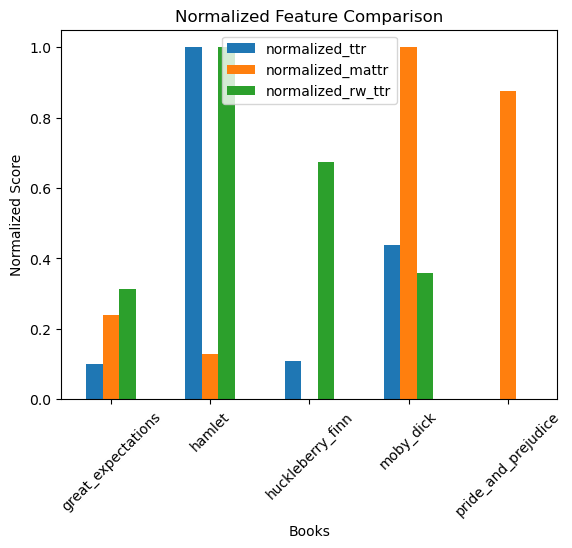

In [18]:
df.set_index("book")[["normalized_ttr", "normalized_mattr", "normalized_rw_ttr"]].plot(kind="bar")

plt.title("Normalized Feature Comparison")
plt.xlabel("Books")
plt.ylabel("Normalized Score")
plt.xticks(rotation=45)

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'normalized_features.png')
plt.show()

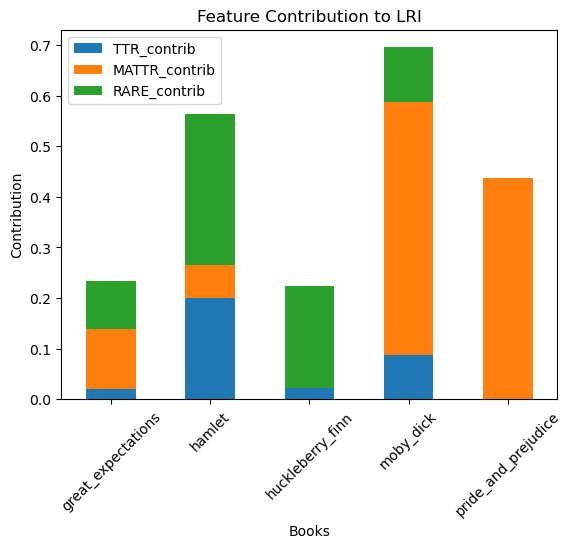

In [19]:
df_contrib = df.copy()

df_contrib["TTR_contrib"] = 0.2 * df_contrib["normalized_ttr"]
df_contrib["MATTR_contrib"] = 0.5 * df_contrib["normalized_mattr"]
df_contrib["RARE_contrib"] = 0.3 * df_contrib["normalized_rw_ttr"]

df_contrib.set_index("book")[["TTR_contrib", "MATTR_contrib", "RARE_contrib"]].plot(kind="bar", stacked=True)

plt.title("Feature Contribution to LRI")
plt.xlabel("Books")
plt.ylabel("Contribution")
plt.xticks(rotation=45)

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'Feature_contribution.png')
plt.show()

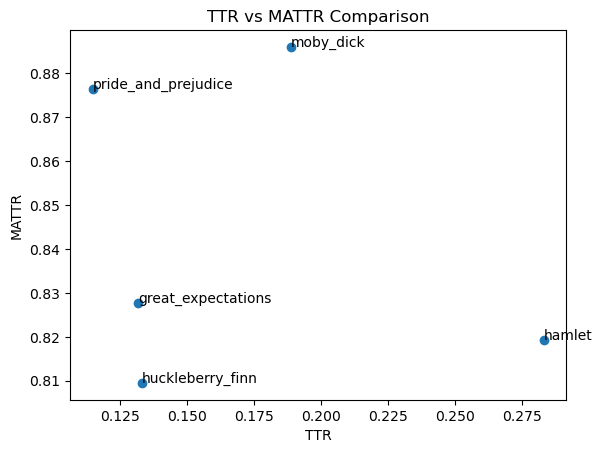

In [20]:
plt.scatter(df["ttr"], df["mattr"])

for i, row in df.iterrows():
    plt.text(row["ttr"], row["mattr"], row["book"])

plt.xlabel("TTR")
plt.ylabel("MATTR")
plt.title("TTR vs MATTR Comparison")

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'TTR_VS_MATTR.png')
plt.show()

key observations:

✅ Hamlet shows  highest TTR but moderate MATTR which is evident that it not as consistently rich as reflected by TTR(complexity overestimation).

✅Mobi Dick has a moderate TTR but highest MATTR which shows that vocabulary is consistently rich(complexity under estimation).

✅Pride and Prejudice has  least TTR but MATTR is significantly high.vocacbulary richness is stable.

✅Huckleberry_finn has low TTR and low  MATTR  ->simple and repetitive vocabulary ,herre both the metrics show the true naature of the text complexity.

✅ Great Expectations exhibit low TTR and moderate MATTR indicating a balanced level of lexical diversity. 

In [21]:
data=[]
for file in os.listdir(data_path):
    if file.endswith('.txt'):
        with open(os.path.join(data_path,file),'r',encoding='utf-8') as f:
            text=f.read()
            tokens=tokenize_text(text)
            window_size=100
            mattr_values=[]
            for i in range(len(tokens)-window_size+1):
                window_tokens=tokens[i:window_size+i]
                ttr_score=calculate_ttr(window_tokens)
                mattr_values.append(ttr_score)
            data.append({
                'book':file.replace('.txt',''),
                'mattr_values':mattr_values
            }) 

df=pd.DataFrame(data)
          
             

In [22]:
df

,book,mattr_values
0,great_expectations,"[0.85, 0.84, 0.84, 0.84, 0.84, 0.83, 0.84, 0.8..."
1,hamlet,"[0.28, 0.27, 0.27, 0.27, 0.28, 0.28, 0.27, 0.2..."
2,huckleberry_finn,"[0.83, 0.82, 0.82, 0.81, 0.82, 0.83, 0.83, 0.8..."
3,moby_dick,"[0.84, 0.84, 0.83, 0.83, 0.83, 0.83, 0.83, 0.8..."
4,pride_and_prejudice,"[0.78, 0.79, 0.8, 0.81, 0.81, 0.82, 0.83, 0.84..."


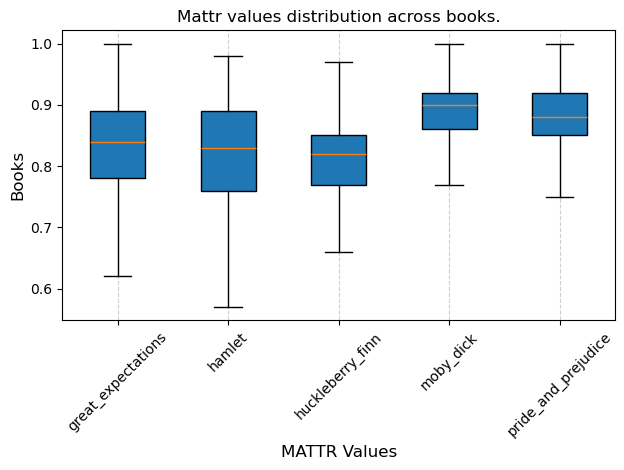

In [23]:
plt.boxplot(df['mattr_values'].tolist(),tick_labels=df['book'],vert=True,patch_artist=True,showfliers=False)
colors = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#F44336"]
for patch, color in zip(plt.gca().artists, colors):
    patch.set_facecolor(color)
plt.title('Mattr values distribution across books.')
plt.xlabel("MATTR Values", fontsize=12)
plt.xticks(rotation=45)
plt.ylabel("Books", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()

fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'LRI_bar_plot.png')


fig=plt.gcf()
save_plot(fig,PLOTS_PATH,'MATTR_distribuiton_across_books.png')
plt.show()

key insights:

✅Moby Dick has rich and consistent vocabulary through out the book.

✅Pride and Prejudice has  tightly packed distribution  whihc shows that there is very less variance and consistent vocabulary usage across entire text.

✅ Hamlet box-plot is wide spread whichh shows high variance ->some parts are simple and easy to understand  while some parts of book are very rich in vocabulary and complex.

✅ Great Expecctations->balanced complexity,neither too wide spread nor too tightly spread.

✅ Huckle_finn is simplest of all->language is more conversational and repetitive.